In [14]:
import pandas as pd
import datetime as dt

customers = pd.read_csv('/content/sconto/customers.csv')
order_items = pd.read_csv('/content/sconto/order_items.csv')
orders = pd.read_csv('/content/sconto/orders.csv')
products = pd.read_csv('/content/sconto/products.csv')
#

In [ ]:
orders.info()
orders['order_date'] = pd.to_datetime(orders['order_datetime'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           2500 non-null   int64         
 1   customer_id        2500 non-null   int64         
 2   order_datetime     2500 non-null   object        
 3   channel            2500 non-null   object        
 4   store              1371 non-null   object        
 5   payment_method     2500 non-null   object        
 6   device_type        2500 non-null   object        
 7   promo_code         727 non-null    object        
 8   order_status       2500 non-null   object        
 9   order_revenue_czk  2500 non-null   float64       
 10  order_cost_czk     2500 non-null   float64       
 11  gross_margin_czk   2500 non-null   float64       
 12  order_date         2500 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory us

In [ ]:
order_items.columns

Index(['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price_czk',
       'discount_pct', 'returned_quantity', 'total_revenue'],
      dtype='object')

In [ ]:
order_items['total_revenue'] = order_items['quantity'] * order_items['unit_price_czk'].round(0)
order_items['unit_price_czk'] = order_items['unit_price_czk'].round(0)

In [ ]:
order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price_czk,discount_pct,returned_quantity,total_revenue
0,1,1,24,2,8849.0,0.030743,2,17698.0
1,2,1,297,1,38856.0,0.014312,1,38856.0
2,3,2,55,2,3195.0,0.152549,0,6390.0
3,4,2,291,1,9203.0,0.133434,0,9203.0
4,5,3,69,1,2347.0,0.182105,0,2347.0


In [ ]:
customer_orders = customers.merge(orders, on='customer_id', how= 'left')

result = (
    customer_orders
    .groupby(['customer_id', 'first_name', 'last_name', 'city'], dropna=False)['order_id']
    .count()
    .reset_index(name='total_orders')
    .sort_values(['total_orders', 'customer_id'], ascending=[False, False])
)

result.head(10)

,customer_id,first_name,last_name,city,total_orders
710,711,Simona,Novotný,Olomouc,9
554,555,Anna,Novotný,Plzeň,9
543,544,Nikola,Pokorný,Brno,9
541,542,Jakub,Pospíšil,Brno,9
160,161,Lukáš,Svoboda,Plzeň,9
3,4,Monika,Jelínek,Ostrava,9
619,620,Monika,Černý,Brno,8
600,601,Daniel,Horák,České Budějovice,8
287,288,Jan,Procházka,Pardubice,8
284,285,Petr,Procházka,Praha,8


In [ ]:
(orders.groupby('customer_id')['order_id']
      .count()
      .reset_index(name='total_orders')
      .sort_values(['total_orders', 'customer_id'], ascending=[False, False])
      .head(10))

,customer_id,total_orders
674,711,9
525,555,9
515,544,9
513,542,9
155,161,9
3,4,9
586,620,8
567,601,8
273,288,8
270,285,8


In [ ]:
plot_data = (orders.groupby(['day_num','day_of_week'])['gross_margin_czk']
.sum()
.reset_index(name='daily_revenue')
.sort_values('day_num', ascending=True).head(10))

In [ ]:
plot_data

,day_num,day_of_week,daily_revenue
0,1,Monday,2966485.86
1,2,Tuesday,3185099.57
2,3,Wednesday,2929040.26
3,4,Thursday,3484878.69
4,5,Friday,2468172.94
5,6,Saturday,3115493.07
6,7,Sunday,2621220.14


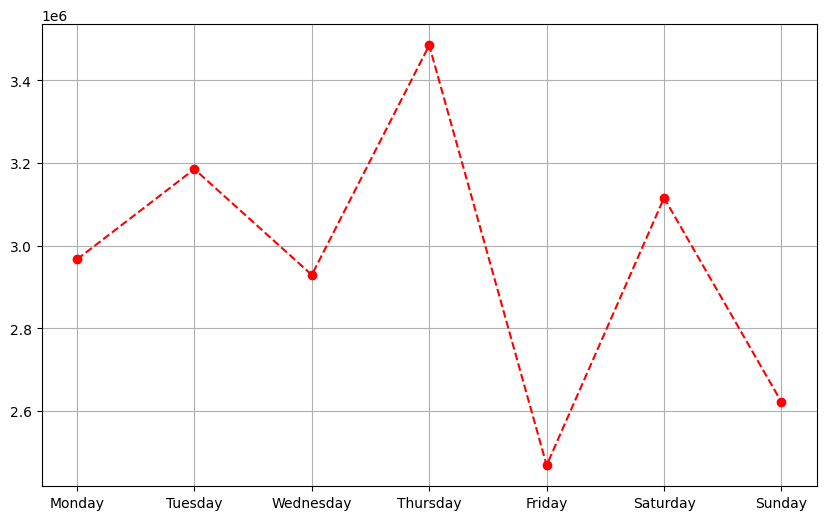

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(plot_data['day_of_week'], plot_data['daily_revenue'], marker='o', linestyle='dashed', color='red')
plt.grid(True)

In [ ]:
orders.dtypes

,0
order_id,int64
customer_id,int64
order_datetime,datetime64[ns]
channel,object
store,object
payment_method,object
device_type,object
promo_code,object
order_status,object
order_revenue_czk,float64


In [ ]:
order_items.head(5)

,order_item_id,order_id,product_id,quantity,unit_price_czk,discount_pct,returned_quantity,total_revenue
0,1,1,24,2,8849.0,0.030743,2,17698.0
1,2,1,297,1,38856.0,0.014312,1,38856.0
2,3,2,55,2,3195.0,0.152549,0,6390.0
3,4,2,291,1,9203.0,0.133434,0,9203.0
4,5,3,69,1,2347.0,0.182105,0,2347.0


In [26]:
product_sales = products.merge(order_items, on='product_id', how='inner')

product_sales['revenue_calc'] = (product_sales['quantity'] * product_sales['unit_price_czk']).round(0)

top_sales = (product_sales
             .groupby(['product_id', 'product_name'], dropna=False)['revenue_calc']
             .agg(
                revenue='sum',
                average='mean',
                counting='count'
             ).round(0)
             .reset_index()
             .sort_values('counting', ascending=False)
)
top_sales.head()

,product_id,product_name,revenue,average,counting
76,78,SoftNest sofa oak,1025399.0,31073.0,33
292,294,CasaLine nightstand walnut,419784.0,13118.0,32
62,64,Nordika dining table walnut,174676.0,5823.0,30
279,281,Praktik nightstand grey,182034.0,6068.0,30
102,104,UrbanWood nightstand white,183211.0,6318.0,29


In [27]:
product_sales.head()

,product_id,sku,product_name,category,sub_category,brand,material,color,list_price_czk,unit_cost_czk,is_active,launch_date,order_item_id,order_id,quantity,unit_price_czk,discount_pct,returned_quantity,revenue_calc
0,1,SKU00001,LumiHome bed frame oak,Beds & Mattresses,bed frame,LumiHome,laminate,oak,33930,22156.62,True,2024-03-30,162,84,1,33444.19,0.014318,0,33444.0
1,1,SKU00001,LumiHome bed frame oak,Beds & Mattresses,bed frame,LumiHome,laminate,oak,33930,22156.62,True,2024-03-30,241,132,2,33930.00,0.000000,0,67860.0
2,1,SKU00001,LumiHome bed frame oak,Beds & Mattresses,bed frame,LumiHome,laminate,oak,33930,22156.62,True,2024-03-30,528,289,1,33610.54,0.009415,0,33611.0
3,1,SKU00001,LumiHome bed frame oak,Beds & Mattresses,bed frame,LumiHome,laminate,oak,33930,22156.62,True,2024-03-30,539,295,1,26196.86,0.227914,0,26197.0
4,1,SKU00001,LumiHome bed frame oak,Beds & Mattresses,bed frame,LumiHome,laminate,oak,33930,22156.62,True,2024-03-30,833,463,1,26137.44,0.229666,0,26137.0


In [ ]:
from numpy import sort
#revenue podle kategorie   quantity * price
orders_items_products = order_items.merge(products, on='product_id', how='left')
orders_items_products['item_revenue'] = orders_items_products['quantity'] * orders_items_products['unit_price_czk']

top_revenue = (
    orders_items_products
    .groupby('category')['item_revenue']
    .sum()
    .reset_index(name='revenue')
    .sort_values('revenue', ascending=False)
)
top_revenue.head()

,category,revenue
0,Beds & Mattresses,22887962.80
6,Sofas & Armchairs,8397895.73
2,Dining,7028153.64
8,Wardrobes & Storage,6790535.71
5,Office,6399508.67


In [ ]:
orders_items_products.head()

,order_item_id,order_id,product_id,quantity,unit_price_czk,discount_pct,returned_quantity,sku,product_name,category,sub_category,brand,material,color,list_price_czk,unit_cost_czk,is_active,launch_date,item_revenue
0,1,1,24,2,8849.32,0.030743,2,SKU00024,Comforto chair oak,Dining,chair,Comforto,solid_wood,oak,9130,4871.44,True,2024-03-18,17698.64
1,2,1,297,1,38855.83,0.014312,1,SKU00297,Oak&Co mattress grey,Beds & Mattresses,mattress,Oak&Co,MDF,grey,39420,19239.58,True,2024-09-12,38855.83
2,3,2,55,2,3194.89,0.152549,0,SKU00055,SoftNest clock oak,Decor,clock,SoftNest,laminate,oak,3770,2233.36,True,2024-09-10,6389.78
3,4,2,291,1,9202.93,0.133434,0,SKU00291,SoftNest office chair green,Office,office chair,SoftNest,laminate,green,10620,7240.34,True,2025-06-07,9202.93
4,5,3,69,1,2347.36,0.182105,0,SKU00069,Oak&Co rug green,Textiles,rug,Oak&Co,MDF,green,2870,1666.45,True,2025-10-28,2347.36


In [ ]:
customer_orders = customers.merge(orders, on='customer_id', how='left')

no_orders = (customer_orders
             [customer_orders['order_id'].isna()]
            [['customer_id', 'first_name', 'last_name', 'city', 'email']]

)
no_orders.head()

,customer_id,first_name,last_name,city,email
44,11,Jakub,Pospíšil,Brno,jakubpospíšil.2341@seznam.cz
234,64,Kristýna,Král,Liberec,kristýnakrál.9268@outlook.com
256,71,Adéla,Kučera,Olomouc,adélakučera.8883@yahoo.com
330,95,Marek,Němec,Brno,marekněmec.7759@gmail.com
410,121,Simona,Dvořák,Hradec Králové,simonadvořák.3964@gmail.com


In [ ]:
no_orders['full_name'] = no_orders['first_name'] + ' ' + no_orders['last_name']
no_orders[no_orders['full_name'].str.contains('Monika', case=False)]


,customer_id,first_name,last_name,city,email,full_name
1182,367,Monika,Pospíšil,Zlín,monikapospíšil.8587@seznam.cz,Monika Pospíšil
2059,642,Monika,Král,Pardubice,monikakrál.4714@gmail.com,Monika Král


In [ ]:
from unidecode import unidecode

In [ ]:
no_orders.head()

,customer_id,first_name,last_name,city,email,full_name
44,11,Jakub,Pospíšil,Brno,jakubpospisil.2341@seznam.cz,JAKUBPOSPISIL.2341@SEZNAM.CZ
234,64,Kristýna,Král,Liberec,kristynakral.9268@outlook.com,KRISTYNAKRAL.9268@OUTLOOK.COM
256,71,Adéla,Kučera,Olomouc,adelakucera.8883@yahoo.com,ADELAKUCERA.8883@YAHOO.COM
330,95,Marek,Němec,Brno,mareknemec.7759@gmail.com,MAREKNEMEC.7759@GMAIL.COM
410,121,Simona,Dvořák,Hradec Králové,simonadvorak.3964@gmail.com,SIMONADVORAK.3964@GMAIL.COM


In [ ]:
no_orders['full_name'] = no_orders['full_name'].str.upper().apply(unidecode)
no_orders['email'] = no_orders['email'].apply(unidecode)

In [ ]:
orders[['promo_code', 'store']].isna().sum().reset_index(name='with NAN')

,index,with NAN
0,promo_code,1773
1,store,1129


In [16]:
orders['date_order'] = pd.to_datetime(orders['order_datetime'])
orders['order_month'] = orders['date_order'].dt.to_period('M')
orders['order_year'] = orders['date_order'].dt.year
orders['order_day'] = orders['date_order'].dt.day
orders['order_months'] = orders['date_order'].dt.month_name()
orders['month_num'] = orders['date_order'].dt.month

orders['order_day_of_week'] = orders['date_order'].dt.day_name()

#orders = orders.drop('order_day_num', axis=1, inplace=True)

#orders = orders.drop('order_monht', axis=1)

orders.head()

,order_id,customer_id,order_datetime,channel,store,payment_method,device_type,promo_code,order_status,order_revenue_czk,order_cost_czk,gross_margin_czk,date_order,order_month,order_year,order_day,order_months,month_num,order_day_of_week
0,1,504,2024-04-13 20:26:00,e-shop,NaN,cash,desktop,NaN,cancelled,0.00,0.00,0.00,2024-04-13 20:26:00,2024-04,2024,13,April,4,Saturday
1,2,368,2024-09-24 13:43:00,store,Liberec,bank_transfer,in_store_kiosk,SPRING15,completed,15592.71,11707.06,3885.65,2024-09-24 13:43:00,2024-09,2024,24,September,9,Tuesday
2,3,117,2025-09-24 11:07:00,e-shop,NaN,cash,in_store_kiosk,SPRING15,completed,2347.36,1666.45,680.91,2025-09-24 11:07:00,2025-09,2025,24,September,9,Wednesday
3,4,789,2025-07-24 12:57:00,store,Olomouc,bank_transfer,in_store_kiosk,NaN,completed,965.23,654.49,310.74,2025-07-24 12:57:00,2025-07,2025,24,July,7,Thursday
4,5,449,2025-04-13 20:07:00,e-shop,NaN,online_card,mobile,BF20,completed,7403.74,5213.10,2190.64,2025-04-13 20:07:00,2025-04,2025,13,April,4,Sunday


In [6]:
count_orders = (
    orders
    .groupby(['order_months', 'month_num'] )['order_id']
    .count()
    .reset_index(name='count_orders')
    .sort_values('month_num', ascending=True)
)
count_orders.head(12)

,order_months,month_num,count_orders
4,January,1,316
3,February,2,266
7,March,3,206
0,April,4,193
8,May,5,212
6,June,6,174
5,July,7,203
1,August,8,169
11,September,9,192
10,October,10,195


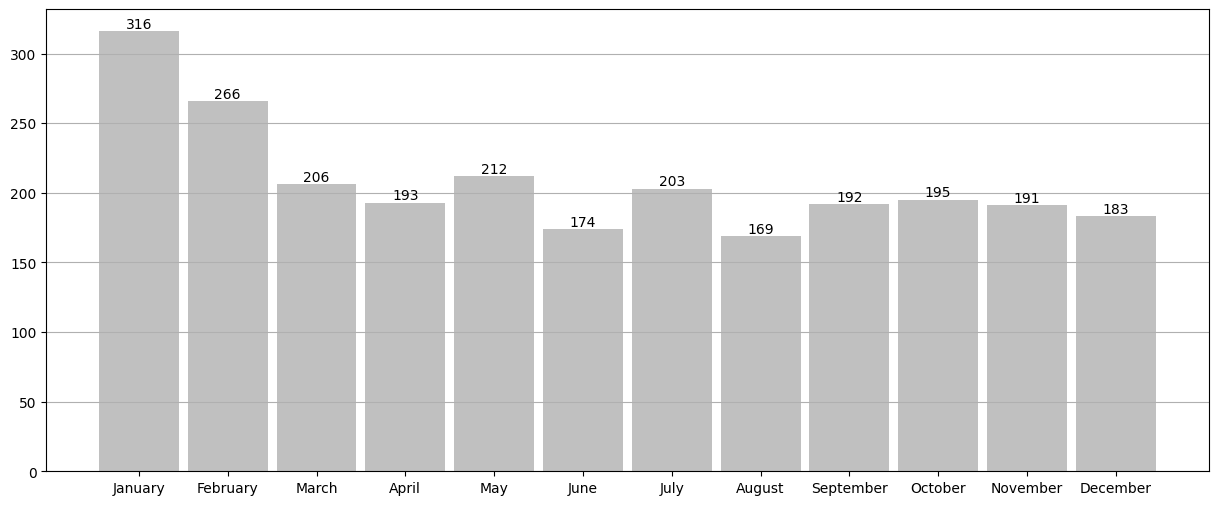

In [ ]:
plt.figure(figsize=(15, 6))
bars = plt.bar(
    count_orders['order_months'],
    count_orders['count_orders'],
    color='silver',
    width=0.9)


plt.bar_label(bars)

plt.grid(axis='y')
plt.show()




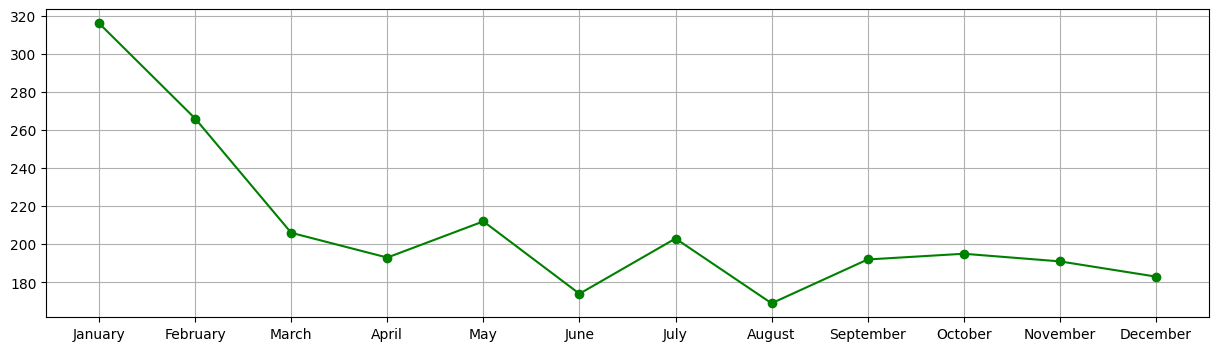

In [ ]:
plt.figure(figsize=(15, 4))
plt.plot(count_orders['order_months'], count_orders['count_orders'], marker= 'o', linestyle='-', color='green')
plt.grid(True)
plt.show()

In [ ]:
days_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

orders['order_day_of_week'] = pd.Categorical(
    orders['order_day_of_week'],
    categories=days_order,
    ordered=True
)

count_orders_day = (
    orders
    .groupby('order_day_of_week')['order_id']
    .count()
    .reset_index(name='count_orders')
    .sort_values('order_day_of_week')
)

count_orders_day

/tmp/ipykernel_219/3059641731.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('order_day_of_week')['order_id']


,order_day_of_week,count_orders
0,Monday,363
1,Tuesday,354
2,Wednesday,345
3,Thursday,384
4,Friday,342
5,Saturday,374
6,Sunday,338


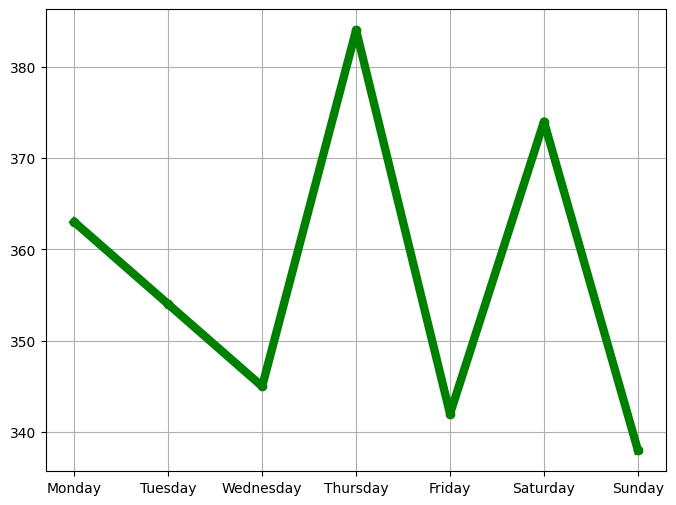

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(count_orders_day['order_day_of_week'], count_orders_day['count_orders'], marker= 'o', linestyle='-', color='green', linewidth=6 )
plt.grid(True)
plt.show()





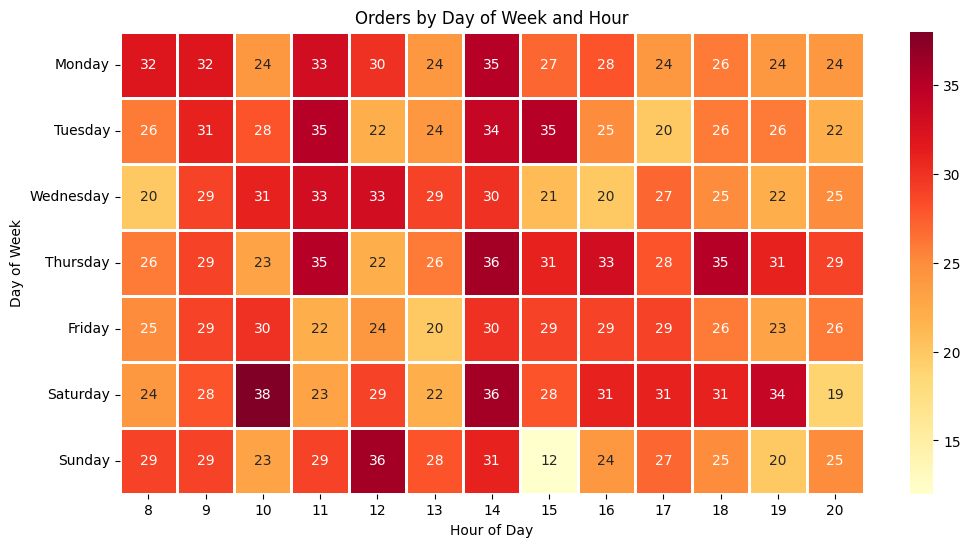

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

orders['day_of_week'] = orders['date_order'].dt.day_name()
orders['hour'] = orders['date_order'].dt.hour

heatmap_data = (
     orders
    .groupby(['day_of_week','hour'])['order_id']
    .count()
    .reset_index()
    .pivot(index='day_of_week', columns='hour', values='order_id')
)

days_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

heatmap_data = heatmap_data.loc[days_order]


plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='' ,
    linewidths=1
)

plt.title("Orders by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

In [19]:
orders.head()

,order_id,customer_id,order_datetime,channel,store,payment_method,device_type,promo_code,order_status,order_revenue_czk,...,gross_margin_czk,date_order,order_month,order_year,order_day,order_months,month_num,order_day_of_week,day_of_week,hour
0,1,504,2024-04-13 20:26:00,e-shop,NaN,cash,desktop,NaN,cancelled,0.00,...,0.00,2024-04-13 20:26:00,2024-04,2024,13,April,4,Saturday,Saturday,20
1,2,368,2024-09-24 13:43:00,store,Liberec,bank_transfer,in_store_kiosk,SPRING15,completed,15592.71,...,3885.65,2024-09-24 13:43:00,2024-09,2024,24,September,9,Tuesday,Tuesday,13
2,3,117,2025-09-24 11:07:00,e-shop,NaN,cash,in_store_kiosk,SPRING15,completed,2347.36,...,680.91,2025-09-24 11:07:00,2025-09,2025,24,September,9,Wednesday,Wednesday,11
3,4,789,2025-07-24 12:57:00,store,Olomouc,bank_transfer,in_store_kiosk,NaN,completed,965.23,...,310.74,2025-07-24 12:57:00,2025-07,2025,24,July,7,Thursday,Thursday,12
4,5,449,2025-04-13 20:07:00,e-shop,NaN,online_card,mobile,BF20,completed,7403.74,...,2190.64,2025-04-13 20:07:00,2025-04,2025,13,April,4,Sunday,Sunday,20


In [24]:
orders.groupby('order_year')['order_id'].count()

,order_id
order_year,
2024,1179
2025,1128
2026,193
